## Step 1: Import packages

In [143]:
import os
import pandas as pd
import numpy as np
import openpyxl
import sklearn


## Step 2: Setup working directory

In [144]:
os.getcwd()

'/Users/markruperto/Desktop/School/GCU/BIT-446/Topic 5'

In [145]:
os.chdir('/Users/markruperto/Desktop/School/GCU/BIT-446/Topic 5')


## Step 3: Import the records 1 through 300 form the dataset FailureRate1

In [146]:
FailureRate = pd.read_excel("FailureRate1.xlsx", nrows=300)

## Step 4: Provide dataset header information including data type

In [147]:
FailureRate.info()
FailureRate.head(300)

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   record                   300 non-null    int64
 1   hours_run                300 non-null    int64
 2   avg_hours_between_maint  300 non-null    int64
 3   model_version            300 non-null    int64
 4   failure                  300 non-null    int64
dtypes: int64(5)
memory usage: 11.8 KB


,record,hours_run,avg_hours_between_maint,model_version,failure
0,1,1005,382,3,0
1,2,1023,380,1,0
2,3,1057,319,1,0
3,4,1063,566,3,0
4,5,1150,767,1,0
...,...,...,...,...,...
295,296,9808,1925,2,0
296,297,9823,1887,2,0
297,298,9870,1510,2,0
298,299,9978,1782,3,0


## Step 5: Define dataset to specify features and target variable

In [148]:
feature_columns = ['hours_run', 'avg_hours_between_maint', 'model_version']
X = FailureRate[feature_columns] #Features
Y = FailureRate.failure          #Target variable

print(X.head())
print(Y.head())

   hours_run  avg_hours_between_maint  model_version
0       1005                      382              3
1       1023                      380              1
2       1057                      319              1
3       1063                      566              3
4       1150                      767              1
0    0
1    0
2    0
3    0
4    0
Name: failure, dtype: int64


## Step 6: Partition X and Y into training and testing sets (70% training; 30% test)

In [149]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.30,random_state=10)

In [150]:
print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)
print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (210, 3)
Y_train shape: (210,)
X_test shape: (90, 3)
Y_test shape: (90,)


## Step 7: Create a Gaussian classifier (naive Bayes)

In [151]:
from sklearn.naive_bayes import GaussianNB
naive_clf = GaussianNB()

## Step 8: Train the model using the training data

In [152]:
naive_clf.fit(X_train, Y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


## Step 9: Predict the response for the test data

In [153]:
naive_clf.predict(X_test)

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0])

## Step 10: Using scikit-learn metrics, obtain the basic performance metrics of the model

In [154]:
from sklearn.metrics import classification_report

print(classification_report(Y_test,naive_clf.predict(X_test)))


              precision    recall  f1-score   support

           0       0.82      1.00      0.90        69
           1       1.00      0.29      0.44        21

    accuracy                           0.83        90
   macro avg       0.91      0.64      0.67        90
weighted avg       0.86      0.83      0.80        90



## Step 11: Create a confusion matrix for the model


[[69  0]
 [15  6]]
69 0 15 6


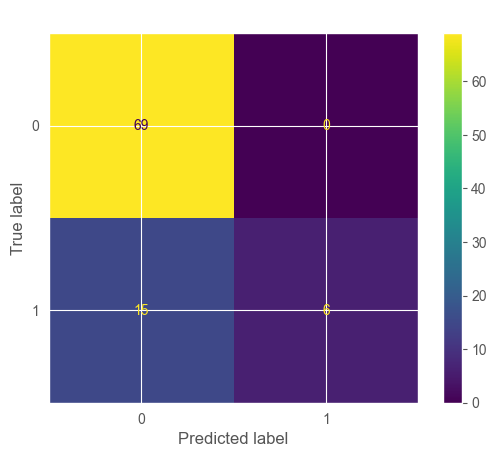

In [155]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test,naive_clf.predict(X_test))
print(cm)

tn = cm[0,0]
fp = cm[0,1]
fn = cm[1,0]
tp = cm[1,1]
print(tn,fp,fn,tp)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix for Gaussian Naive Bayes Model")
plt.show()

In [156]:
#Compute metrics from confusion metrics
#accuracy = (tp + tn) / (tp + fp + fn + tn)
#precision = tp / (tp + fp)
#recall = tp / (tp + fn)
#f1_score = 2 * (precision * recall) / (precision + recall)

#print(f'accuracy = {accuracy:.2f}')
#print(f'precision = {precision:.2f}')
#print(f'recall = {recall:.2f}')
#print(f'f1_score = {f1_score:.2f}')


## Step 12: Create visualizations related to model performance using kds package

In [169]:
import kds

Y_prob = naive_clf.predict_proba(X_test)[:, 1]

results_df = pd.DataFrame({
    'actual': Y_test,
    'probability': Y_prob
})

print(results_df)

     actual  probability
24        0     0.003496
65        1     0.507904
113       0     0.167477
261       0     0.020347
188       0     0.038890
..      ...          ...
169       0     0.128497
49        1     0.544749
223       0     0.042375
196       0     0.027557
58        1     0.487982

[90 rows x 2 columns]


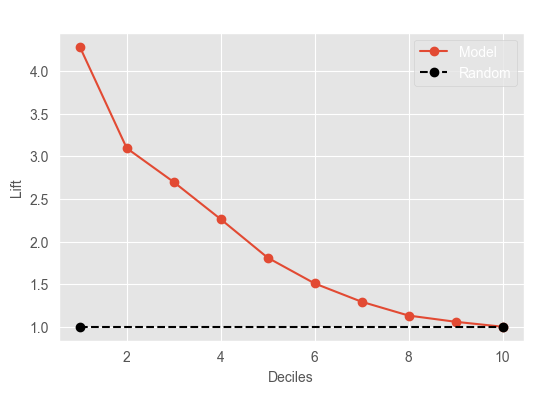

In [158]:
#Lift plot
plt.figure(figsize=(6, 4))
kds.metrics.plot_lift(y_true=results_df['actual'], y_prob=results_df['probability'])
plt.style.use('ggplot')
plt.title("Lift Plot")
plt.show()

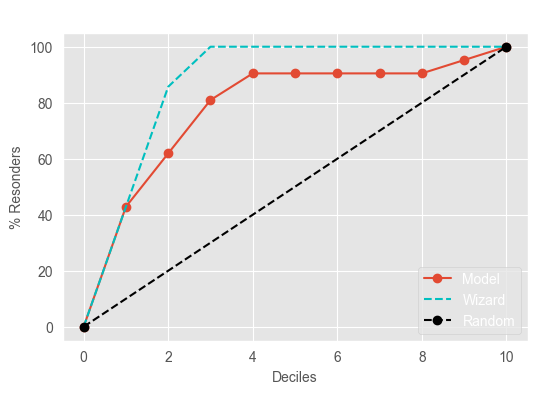

In [159]:
#Cumulative gain plot
plt.figure(figsize=(6, 4))
kds.metrics.plot_cumulative_gain(y_true=results_df['actual'], y_prob=results_df['probability'])
plt.style.use('ggplot')
plt.title("Cumulative Gain Plot")
plt.show()

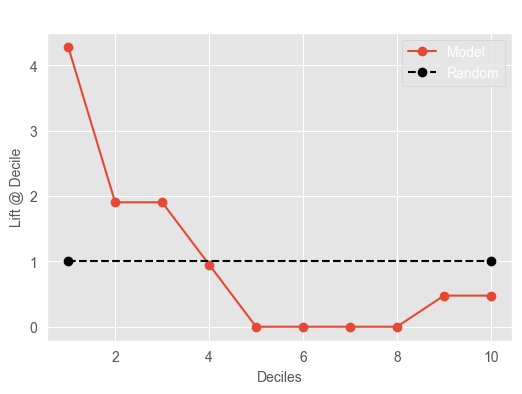

In [160]:
#Decile-wise Lift Plot
plt.figure(figsize=(6, 4))
kds.metrics.plot_lift_decile_wise(y_true=results_df['actual'], y_prob=results_df['probability'])
plt.style.use('ggplot')
plt.title("Decile-wise Lift Plot")
plt.show()

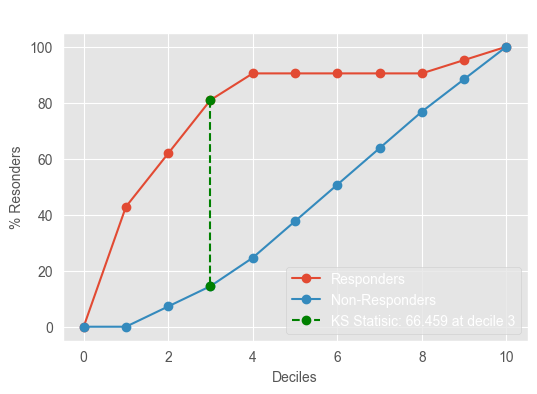

In [167]:
#KS statistic plot
plt.figure(figsize=(6, 4))
kds.metrics.plot_ks_statistic(y_true=results_df['actual'], y_prob=results_df['probability'])
plt.style.use('ggplot')
plt.title("KS Statistic Plot")
plt.show()

LABELS INFO:

 prob_min         : Minimum probability in a particular decile
 prob_max         : Minimum probability in a particular decile
 prob_avg         : Average probability in a particular decile
 cnt_events       : Count of events in a particular decile
 cnt_resp         : Count of responders in a particular decile
 cnt_non_resp     : Count of non-responders in a particular decile
 cnt_resp_rndm    : Count of responders if events assigned randomly in a particular decile
 cnt_resp_wiz     : Count of best possible responders in a particular decile
 resp_rate        : Response Rate in a particular decile [(cnt_resp/cnt_cust)*100]
 cum_events       : Cumulative sum of events decile-wise 
 cum_resp         : Cumulative sum of responders decile-wise 
 cum_resp_wiz     : Cumulative sum of best possible responders decile-wise 
 cum_non_resp     : Cumulative sum of non-responders decile-wise 
 cum_events_pct   : Cumulative sum of percentages of events decile-wise 
 cum_resp_pct     : Cu

,decile,prob_min,prob_max,prob_avg,cnt_cust,cnt_resp,cnt_non_resp,cnt_resp_rndm,cnt_resp_wiz,resp_rate,cum_cust,cum_resp,cum_resp_wiz,cum_non_resp,cum_cust_pct,cum_resp_pct,cum_resp_pct_wiz,cum_non_resp_pct,KS,lift
0,1,0.457,0.577,0.522,9.0,9.0,0.0,2.1,9,100.000,9.0,9.0,9,0.0,10.0,42.857,42.857,0.000,42.857,4.286
1,2,0.324,0.427,0.365,9.0,4.0,5.0,2.1,9,44.444,18.0,13.0,18,5.0,20.0,61.905,85.714,7.246,54.659,3.095
2,3,0.248,0.318,0.276,9.0,4.0,5.0,2.1,3,44.444,27.0,17.0,21,10.0,30.0,80.952,100.000,14.493,66.459,2.698
3,4,0.148,0.241,0.189,9.0,2.0,7.0,2.1,0,22.222,36.0,19.0,21,17.0,40.0,90.476,100.000,24.638,65.838,2.262
4,5,0.105,0.144,0.130,9.0,0.0,9.0,2.1,0,0.000,45.0,19.0,21,26.0,50.0,90.476,100.000,37.681,52.795,1.810
5,6,0.075,0.094,0.086,9.0,0.0,9.0,2.1,0,0.000,54.0,19.0,21,35.0,60.0,90.476,100.000,50.725,39.751,1.508
6,7,0.042,0.071,0.055,9.0,0.0,9.0,2.1,0,0.000,63.0,19.0,21,44.0,70.0,90.476,100.000,63.768,26.708,1.293
7,8,0.028,0.039,0.032,9.0,0.0,9.0,2.1,0,0.000,72.0,19.0,21,53.0,80.0,90.476,100.000,76.812,13.664,1.131
8,9,0.009,0.020,0.014,9.0,1.0,8.0,2.1,0,11.111,81.0,20.0,21,61.0,90.0,95.238,100.000,88.406,6.832,1.058
9,10,0.003,0.009,0.006,9.0,1.0,8.0,2.1,0,11.111,90.0,21.0,21,69.0,100.0,100.000,100.000,100.000,0.000,1.000


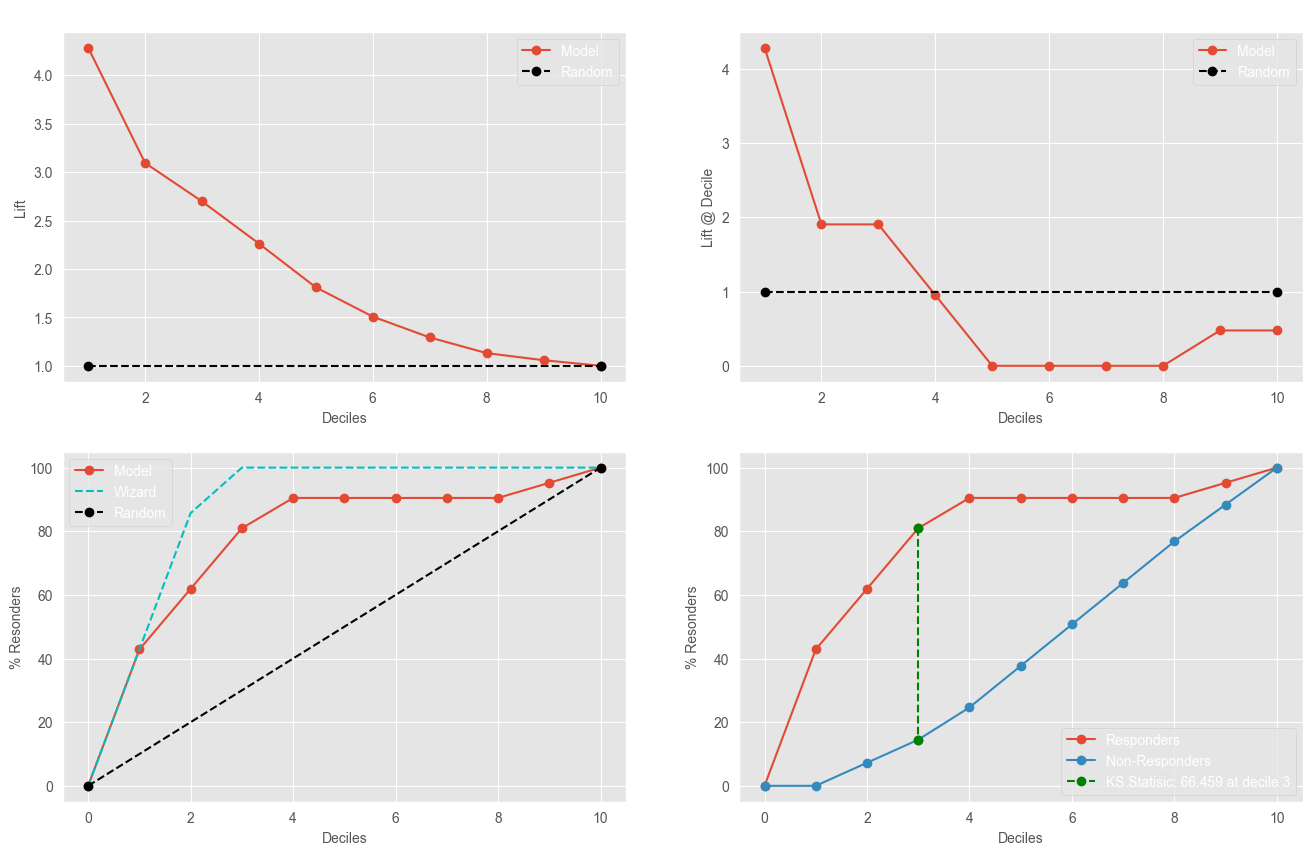

In [162]:
#metrics.report
import kds

plt.style.use('ggplot')

kds.metrics.report(
    y_true=results_df['actual'],
    y_prob=results_df['probability']
)

## Step 13: Conclusion

The Gaussian Naive Bayes model achieved an accuracy of 83%, meaning most predictions are correct overall. However, the results show a clear imbalance. The model performs very well at predicting non-failure cases, correctly identifying all of them. In contrast, it performs poorly at predicting failures. While it is very precise when it does predict a failure, it only identifies 29% of actual failures, meaning most are missed. This is a serious issue because missed failures can lead to real-world risks.

The lift plot shows the model performs slightly better than random guessing, especially for the highest-risk cases, but the improvement is not strong or consistent. The cumulative gain plot also shows only moderate improvement, indicating the model does not capture enough failure cases early.

Overall, this model should not be used for predicting failures. Its low recall makes it unreliable, and improvements are needed before it can support real-world decisions.